# Inference Check

In [1]:
import os

os.chdir("..")

from dataset import UnlabeledDetectionDataset
from network import FRCNNDetector

Load data:

In [2]:
from pathlib import Path
from training import explore_dataset, INFERENCE_TRANSFORMS

df = explore_dataset(Path("../data_det_public/data_det_public"))
unlabeled_df = UnlabeledDetectionDataset(df, INFERENCE_TRANSFORMS)

Inference visualizer:

In [3]:
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from numpy.typing import NDArray

MEAN = [81.7474, 59.7219, 70.0178]
STD = [47.6729, 41.8091, 46.3294]


def prepare(image: torch.Tensor) -> NDArray:
    image = image.permute(1, 2, 0)
    image = image.cpu().numpy()
    image = image.copy()
    for i in range(3):
        image[:, :, i] = image[:, :, i] * STD[i] + MEAN[i]
    return image.astype(np.uint8)


@torch.no_grad()
def run_inference_and_plot(
    model: torch.nn.Module, image: torch.Tensor, score_thresh: float
) -> None:
    model.eval()

    images = [image]
    outputs = model(images)
    print(outputs)
    outputs = outputs[0]
    boxes = outputs["boxes"].cpu()
    scores = outputs["scores"].cpu()
    labels = outputs["labels"].cpu()

    # -----------------------
    # Filter predictions
    # -----------------------
    keep = scores >= score_thresh
    boxes = boxes[keep]
    scores = scores[keep]
    labels = labels[keep]

    # -----------------------
    # Convert image for plotting
    # -----------------------
    img = prepare(image)
    fig, ax = plt.subplots(1, figsize=(10, 8))
    ax.imshow(img)

    # -----------------------
    # Draw boxes
    # -----------------------
    for box, score, label in zip(boxes, scores, labels):
        xmin, ymin, xmax, ymax = box

        rect = patches.Rectangle(
            (xmin, ymin),
            xmax - xmin,
            ymax - ymin,
            linewidth=2,
            edgecolor="red",
            facecolor="none",
        )

        ax.add_patch(rect)
        ax.text(
            xmin,
            ymin,
            f"{label.item()} {score:.2f}",
            color="white",
            bbox=dict(facecolor="red", alpha=0.5),
        )

    plt.axis("off")
    plt.show()

Sample inference:

In [ ]:
model = FRCNNDetector()
state_dict = torch.load("model.pt")
model.load_state_dict(state_dict)
model.eval()

[{'boxes': tensor([[   0.0000,  204.7287,  273.4702,  323.6090],
        [ 773.0061,  161.1896,  971.8817,  306.1096],
        [ 948.2498,  148.8219, 1024.0000,  297.2051],
        [ 519.3989,  197.3973,  823.4271,  317.3964],
        [   2.4470,  268.7834,   93.9300,  452.6258],
        [ 523.6938,  201.3709,  682.7329,  315.6281],
        [ 593.6954,  175.8039,  967.4619,  306.0066],
        [   0.0000,  313.4813,  103.9815,  409.5109],
        [ 702.9860,  227.9813,  813.0900,  302.7557],
        [ 286.5592,  185.1469, 1004.5217,  294.3100],
        [   0.0000,  342.7640,   77.2340,  444.6544],
        [ 942.0248,  148.1112, 1024.0000,  214.9320],
        [ 145.8799,    0.0000,  981.3076,  306.8216],
        [ 881.7158,  134.7544, 1024.0000,  314.7093],
        [ 717.3051,  209.8364, 1014.3775,  296.5554],
        [ 622.5178,  186.2546,  750.0345,  239.4943],
        [ 489.4645,   36.4910,  850.9635,  317.8133],
        [ 478.4622,  209.3596,  582.7323,  281.3075],
        [   7.177

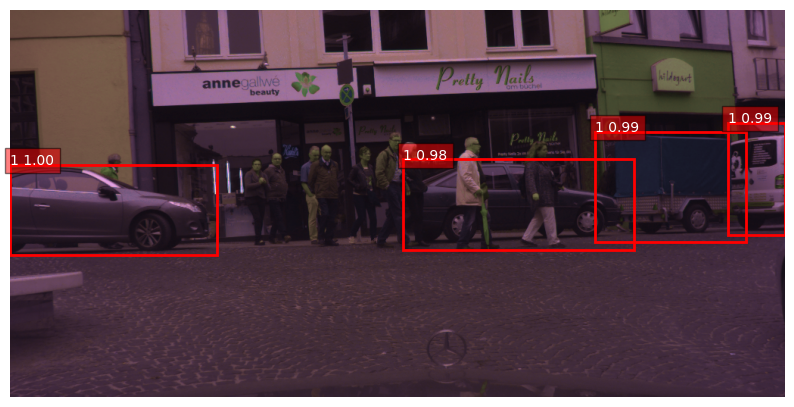

In [6]:
run_inference_and_plot(model, unlabeled_df[15][0], 0.9)